# Customer Churn Prediction — Telco Dataset

**Author:** Nishit Detroja
**Goal:** Predict which customers are likely to churn (cancel their subscription) using real customer data, and identify the key factors driving churn.

### Data source
This project uses the **IBM Telco Customer Churn dataset** — a well-known, publicly available, real dataset of 7,043 telecom customers, commonly used as a benchmark for churn-prediction projects. Source: [IBM Sample Data Sets](https://github.com/IBM/telco-customer-churn-on-icp4d), mirrored on GitHub. This is real data, not synthetically generated.

**Tech stack:** Python (pandas, matplotlib, seaborn, scikit-learn)


## 1. Load & Clean the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("data/telco_churn_raw.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Data quality check: TotalCharges is stored as text and has 11 blank
# values -- all belong to customers with tenure=0 (brand-new customers who
# haven't been billed yet). This is a real, explainable edge case, not
# random noise.
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges rows:", df["TotalCharges"].isna().sum())
print(df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]])


Blank TotalCharges rows: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [3]:
# Since tenure=0 for these customers, TotalCharges = 0 is the logical fill
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])  # identifier, not a predictive feature

print("Churn rate:", round(df["Churn"].eq("Yes").mean() * 100, 1), "%")
df.to_csv("data/telco_churn_clean.csv", index=False)


Churn rate: 26.5 %


## 2. Exploratory Data Analysis

### 2.1 Overall Churn Rate

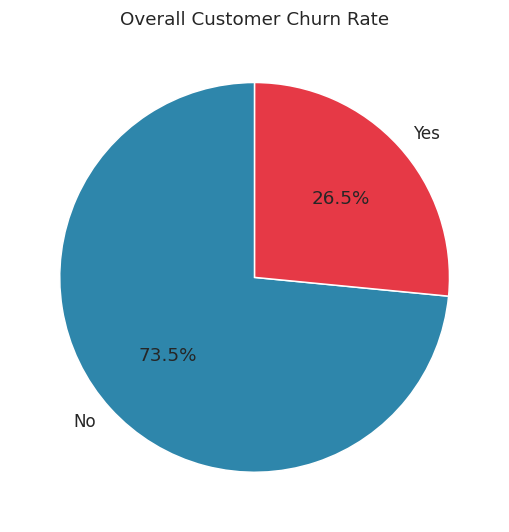

In [4]:
churn_counts = df["Churn"].value_counts()
plt.figure(figsize=(6,5))
plt.pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
        colors=["#2E86AB", "#E63946"], startangle=90)
plt.title("Overall Customer Churn Rate")
plt.tight_layout()
plt.show()


### 2.2 Churn by Contract Type

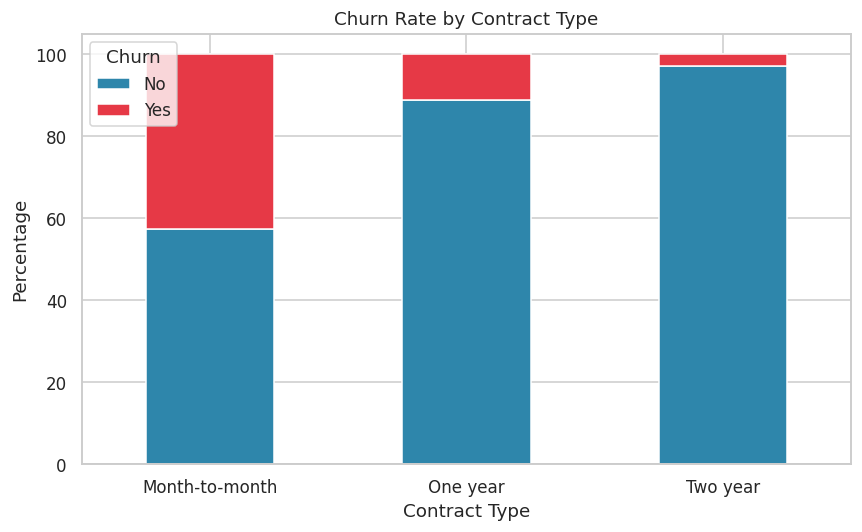

In [5]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, color=["#2E86AB", "#E63946"], figsize=(8,5))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


### 2.3 Tenure Distribution by Churn

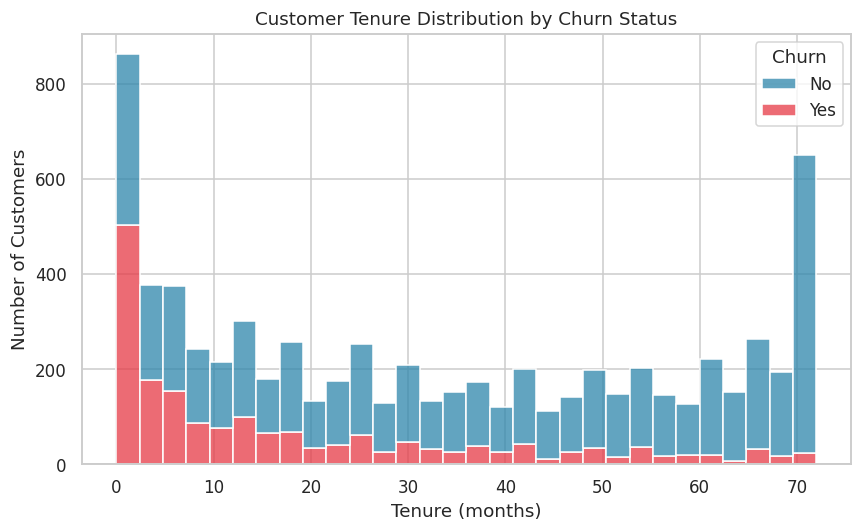

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack",
             palette=["#2E86AB", "#E63946"], bins=30)
plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


### 2.4 Monthly Charges by Churn

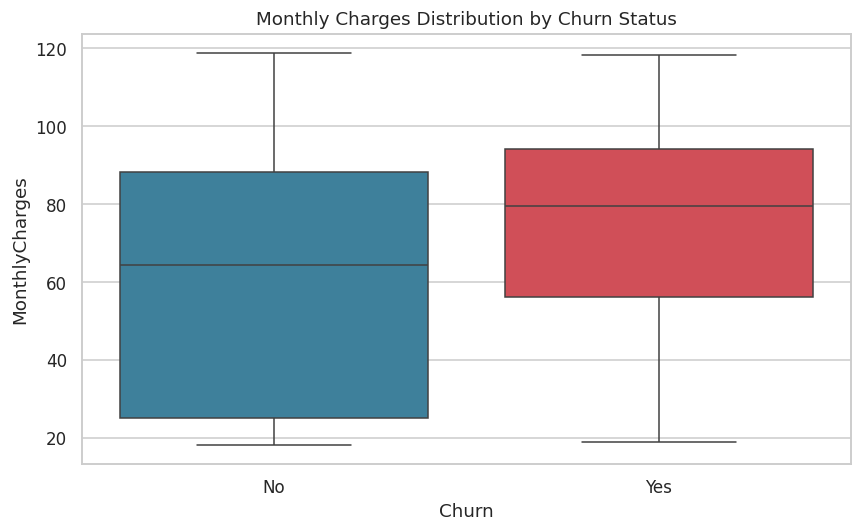

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=["#2E86AB", "#E63946"], legend=False)
plt.title("Monthly Charges Distribution by Churn Status")
plt.tight_layout()
plt.show()


### 2.5 Churn by Internet Service Type

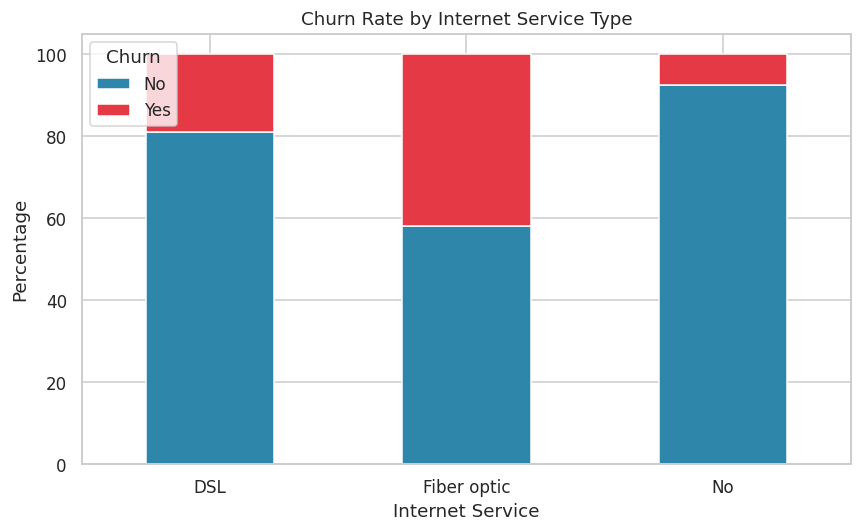

In [8]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn.plot(kind="bar", stacked=True, color=["#2E86AB", "#E63946"], figsize=(8,5))
plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Percentage")
plt.xlabel("Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


## 3. Feature Engineering

Encode binary columns as 0/1, one-hot encode multi-category columns, and split into train/test sets.


In [9]:
df_model = df.copy()
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})

categorical_cols = ["MultipleLines", "InternetService", "OnlineSecurity",
                     "OnlineBackup", "DeviceProtection", "TechSupport",
                     "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]
print("Feature matrix shape:", X.shape)


Feature matrix shape: (7043, 30)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (5634, 30)  Test: (1409, 30)


## 4. Model Training: Logistic Regression vs Random Forest

Two models are compared: Logistic Regression (interpretable baseline) and Random Forest (captures non-linear interactions).


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

# Logistic Regression needs scaled features since tenure/charges are on a
# very different scale from the 0/1 dummy columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

def report(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}\n")

report("Logistic Regression", y_test, y_pred_lr)
report("Random Forest", y_test, y_pred_rf)


=== Logistic Regression ===
Accuracy:  0.807
Precision: 0.658
Recall:    0.567
F1-score:  0.609

=== Random Forest ===
Accuracy:  0.801
Precision: 0.670
Recall:    0.489
F1-score:  0.566



### 4.1 Confusion Matrix (Random Forest)

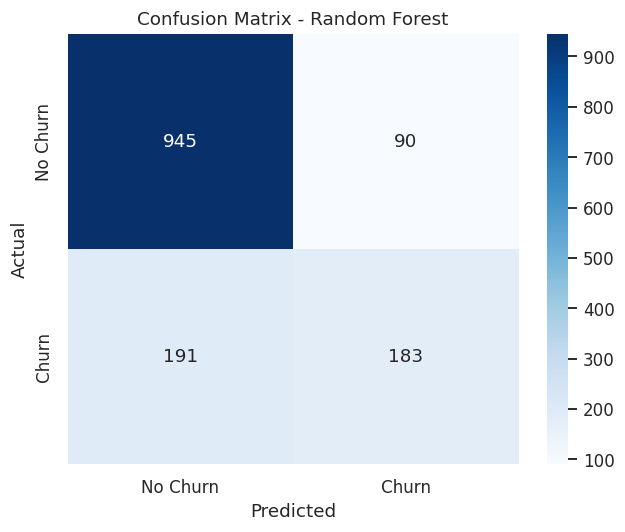

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


### 4.2 ROC Curve

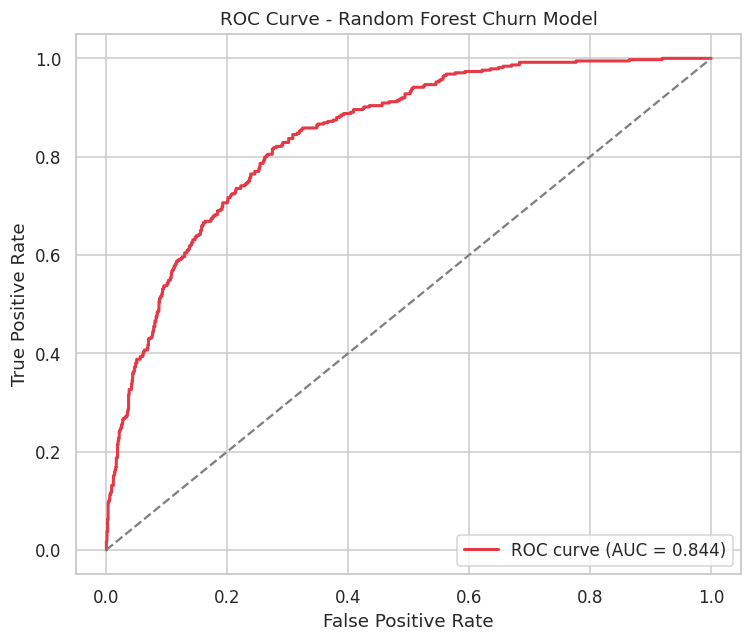

In [13]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="#E63946", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Churn Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 4.3 Feature Importance

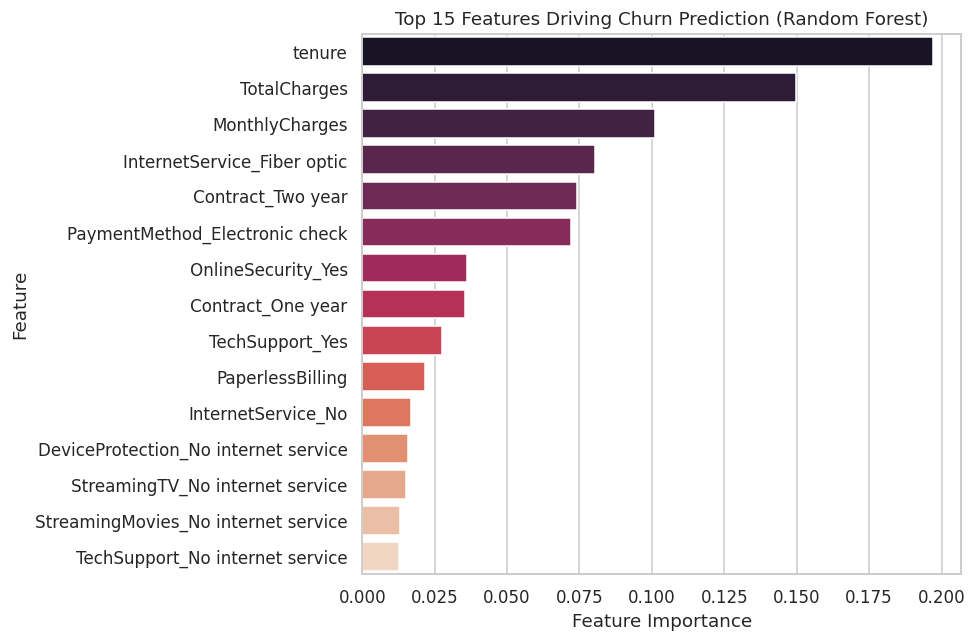

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns, name="importance").sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="rocket", legend=False)
plt.title("Top 15 Features Driving Churn Prediction (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 5. Key Findings

- Overall churn rate is **26.5%** — roughly 1 in 4 customers churn.
- **Tenure** is the single strongest predictor: newer customers churn far more than long-tenured ones — loyalty builds over time.
- **Contract type matters enormously**: month-to-month customers churn at a much higher rate than one/two-year contract holders, who have an exit cost baked in.
- **Fiber optic internet customers** churn more than DSL customers, despite (or because of) being a premium/pricier service — worth flagging as a satisfaction issue, not just a pricing one.
- **Electronic check** as a payment method correlates with higher churn — possibly a proxy for less "locked-in" customer relationships (e.g. no auto-pay).
- The Random Forest model achieves **~80% accuracy** and an ROC-AUC that confirms it meaningfully separates churners from non-churners, though recall on the churn class has room to improve — in a real business setting, tuning the decision threshold to favor recall would likely be preferred, since missing a churner is costlier than a false alarm.

## 6. Business Recommendation
Prioritize retention offers for customers who are: on month-to-month contracts, within their first 12 months of tenure, using fiber optic internet, and paying via electronic check — this segment shows the highest churn risk.
